# ═══════════════════════════════════════
# WEEK 4, DAY 1: TWO-QUBIT CIRCUITS
# ═══════════════════════════════════════
#
# Today's Goal: Understand two-qubit systems
# 
# Key Concepts:
# - Two qubits = four possible states
# - |00⟩, |01⟩, |10⟩, |11⟩
# - Reading two-qubit measurement results
# - Preparing for entanglement!
#
# This is where quantum computing gets REALLY interesting!

In [2]:
# Import all tools for two-qubit circuits
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

# Create simulator
simulator = AerSimulator()

print("✅ Week 4 tools ready!")
print("✅ Entering the multi-qubit world!")

✅ Week 4 tools ready!
✅ Entering the multi-qubit world!


# Understanding Two-Qubit States
#
# With ONE qubit, we had 2 basis states:
# - |0⟩ and |1⟩
#
# With TWO qubits, we have 4 basis states:
# - |00⟩ = both qubits are 0
# - |01⟩ = first qubit is 0, second qubit is 1
# - |10⟩ = first qubit is 1, second qubit is 0
# - |11⟩ = both qubits are 1
#
# Notation: |qubit₀ qubit₁⟩
# - First digit = state of qubit 0
# - Second digit = state of qubit 1
#
# This is like binary numbers!
# |00⟩ = 0 in decimal
# |01⟩ = 1 in decimal
# |10⟩ = 2 in decimal
# |11⟩ = 3 in decimal

In [2]:
# Visualizing two separate qubits

print("═══════════════════════════════════")
print("TWO QUBITS AS SEPARATE SYSTEMS")
print("═══════════════════════════════════")
print()

print("Qubit 0: Can be |0⟩ or |1⟩")
print("Qubit 1: Can be |0⟩ or |1⟩")
print()

print("All possible combinations:")
print()
print("  Qubit 0  │  Qubit 1  │  Combined State")
print("  ─────────┼───────────┼────────────────")
print("     0     │     0     │      |00⟩")
print("     0     │     1     │      |01⟩")
print("     1     │     0     │      |10⟩")
print("     1     │     1     │      |11⟩")
print()

print("Total: 2 × 2 = 4 possible states")
print()
print("With n qubits: 2ⁿ possible states!")
print("  3 qubits → 8 states")
print("  10 qubits → 1,024 states")
print("  50 qubits → 1,125,899,906,842,624 states! 🤯")

═══════════════════════════════════
TWO QUBITS AS SEPARATE SYSTEMS
═══════════════════════════════════

Qubit 0: Can be |0⟩ or |1⟩
Qubit 1: Can be |0⟩ or |1⟩

All possible combinations:

  Qubit 0  │  Qubit 1  │  Combined State
  ─────────┼───────────┼────────────────
     0     │     0     │      |00⟩
     0     │     1     │      |01⟩
     1     │     0     │      |10⟩
     1     │     1     │      |11⟩

Total: 2 × 2 = 4 possible states

With n qubits: 2ⁿ possible states!
  3 qubits → 8 states
  10 qubits → 1,024 states
  50 qubits → 1,125,899,906,842,624 states! 🤯


# Two-Qubit States as Vectors
#
# Remember: quantum states are vectors
#
# One qubit: 2-component vector
# [α, β] for amplitudes of |0⟩ and |1⟩
#
# Two qubits: 4-component vector
# [α₀₀, α₀₁, α₁₀, α₁₁]
# 
# Where:
# - α₀₀ = amplitude for |00⟩
# - α₀₁ = amplitude for |01⟩
# - α₁₀ = amplitude for |10⟩
# - α₁₁ = amplitude for |11⟩
#
# Example: The |00⟩ state
# Vector form: [1, 0, 0, 0]
# - 100% amplitude in |00⟩
# - 0% amplitude in |01⟩, |10⟩, |11⟩
#
# This is like [1, 0] for single qubit,
# but with 4 components instead of 2!

In [3]:
# The four basis states in vector form

print("═══════════════════════════════════")
print("FOUR BASIS STATES")
print("═══════════════════════════════════")
print()

states = {
    "|00⟩": [1, 0, 0, 0],
    "|01⟩": [0, 1, 0, 0],
    "|10⟩": [0, 0, 1, 0],
    "|11⟩": [0, 0, 0, 1]
}

for state_name, vector in states.items():
    print(f"{state_name:6} = {vector}")
    print(f"        Meaning: Definitely in state {state_name}")
    print()

print("Notice: Each basis state has amplitude 1 in one position,")
print("        and amplitude 0 everywhere else!")
print()
print("Just like single-qubit basis states |0⟩ and |1⟩,")
print("but now with 4 possibilities instead of 2!")

═══════════════════════════════════
FOUR BASIS STATES
═══════════════════════════════════

|00⟩   = [1, 0, 0, 0]
        Meaning: Definitely in state |00⟩

|01⟩   = [0, 1, 0, 0]
        Meaning: Definitely in state |01⟩

|10⟩   = [0, 0, 1, 0]
        Meaning: Definitely in state |10⟩

|11⟩   = [0, 0, 0, 1]
        Meaning: Definitely in state |11⟩

Notice: Each basis state has amplitude 1 in one position,
        and amplitude 0 everywhere else!

Just like single-qubit basis states |0⟩ and |1⟩,
but now with 4 possibilities instead of 2!


# Creating Two-Qubit Circuits in Qiskit
#
# For one qubit, we wrote:
# qc = QuantumCircuit(1, 1)
# - 1 qubit, 1 classical bit
#
# For two qubits, we write:
# qc = QuantumCircuit(2, 2)
# - 2 qubits, 2 classical bits
#
# The qubits are numbered 0 and 1:
# - qubit 0 = first qubit (top wire in circuit diagram)
# - qubit 1 = second qubit (bottom wire in circuit diagram)
#
# Classical bits store measurement results:
# - classical bit 0 stores result from qubit 0
# - classical bit 1 stores result from qubit 1

In [4]:
# Step 1: Create a two-qubit circuit
print("Creating first two-qubit circuit...")
print()

# Create circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)

print("✅ Circuit created!")
print()
print("Qubits:", qc.num_qubits)
print("Classical bits:", qc.num_clbits)
print()
print("Qubit 0: top wire (first qubit)")
print("Qubit 1: bottom wire (second qubit)")

Creating first two-qubit circuit...

✅ Circuit created!

Qubits: 2
Classical bits: 2

Qubit 0: top wire (first qubit)
Qubit 1: bottom wire (second qubit)


Empty two-qubit circuit:



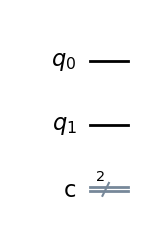

In [6]:
# Draw the circuit (no gates yet!)
print("Empty two-qubit circuit:")
print()
qc.draw('mpl')


# **Run it:** Shift + Enter

# **You should see:**

# What State Does the Circuit Start In?
#
# DEFAULT: All qubits start in |0⟩
#
# For two qubits:
# - Qubit 0 starts in |0⟩
# - Qubit 1 starts in |0⟩
# - Combined: |00⟩
#
# Vector form: [1, 0, 0, 0]
# - 100% amplitude in |00⟩
# - 0% in |01⟩, |10⟩, |11⟩
#
# This is the "computational basis state" |00⟩
# - Also called the "ground state"
# - Or the "all-zeros state"
#
# Every quantum circuit starts in |00...0⟩
# (all qubits initialized to 0)

Circuit that measure with no Gates


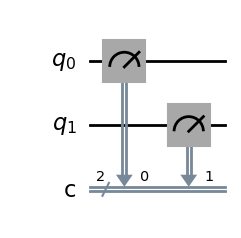

{'00': 1024}


In [16]:
# Import all tools for two-qubit circuits
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

# Create simulator
simulator = AerSimulator()

# Verify Initial State
qc_test = QuantumCircuit(2, 2)

# Measure qubits

qc_test.measure([0, 1],[0, 1])

print("Circuit that measure with no Gates")

display(qc_test.draw('mpl'))

job_test = simulator.run(transpile(qc_test,simulator), shots=1024)
counts_test = job_test.result().get_counts()

print(counts_test)




Circuit for |00⟩


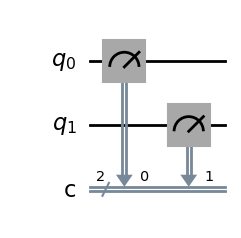

Circuit for |01⟩


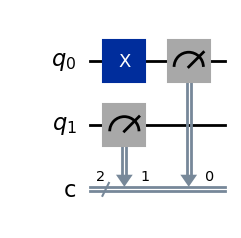

Circuit for |10⟩


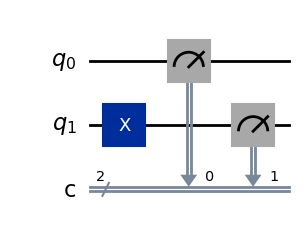

Circuit for |11⟩


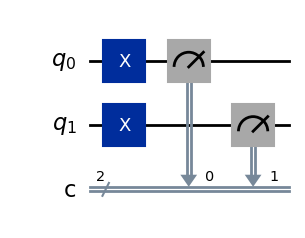

In [25]:
# Let's create circuit that give all possible results

# Circuit 1: Should give '00'
qc_00 = QuantumCircuit(2, 2)
qc_00.measure([0, 1],[0, 1])

#Circuit 2: Should give '01'
qc_01 = QuantumCircuit(2, 2)
qc_01.x(0) # Flip qubit 0 to |1>
qc_01.measure([0,1], [0,1])

# Circuit 3: Should give '10'
qc_10 = QuantumCircuit(2, 2)
qc_10.x(1) #Flip qubit 1 to |1>
qc_10.measure([0,1], [0,1])

# Circuit 4: Should give '11'
qc_11 = QuantumCircuit(2, 2)
qc_11.x(0) # Flip qubit 0 to |1>
qc_11.x(1) #Flip qubit 1 to |1>
qc_11.measure([0,1], [0,1])

circuits = [
    ("|00⟩", qc_00),
    ("|01⟩", qc_01),
    ("|10⟩", qc_10),
    ("|11⟩", qc_11)
]

for label, qc in circuits:
    print(f"Circuit for {label}")
    display(qc.draw("mpl"))




Trying to write code for circuit

Run All Four and Verify


In [5]:
# Import all tools for two-qubit circuits
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

# Create simulator
simulator = AerSimulator()

# Circuit 1: Should give '00'
qc_00 = QuantumCircuit(2, 2)
qc_00.measure([0, 1],[0, 1])

#Circuit 2: Should give '01'
qc_01 = QuantumCircuit(2, 2)
qc_01.x(0) # Flip qubit 0 to |1>
qc_01.measure([0,1], [0,1])

# Circuit 3: Should give '10'
qc_10 = QuantumCircuit(2, 2)
qc_10.x(1) #Flip qubit 1 to |1>
qc_10.measure([0,1], [0,1])

# Circuit 4: Should give '11'
qc_11 = QuantumCircuit(2, 2)
qc_11.x(0) # Flip qubit 0 to |1>
qc_11.x(1) #Flip qubit 1 to |1>
qc_11.measure([0,1], [0,1])

print("Run all four circuits...\n")

for circuit, expected in [
    (qc_00, '00'),
    (qc_01, '01'),
    (qc_10, '10'),
    (qc_11, '11')
]:
    job = simulator.run(transpile(circuit, simulator), shots=1024)
    counts = job.result().get_counts()

    measured = max(counts, key=counts.get)

    print(f"Expected: {expected} -> Got: {measured}")

    if measured == expected:
        print("correct!")
    else:
        print("Unexpected")

    print()

Run all four circuits...

Expected: 00 -> Got: 00
correct!

Expected: 01 -> Got: 01
correct!

Expected: 10 -> Got: 10
correct!

Expected: 11 -> Got: 11
correct!



Now I try to run above code on my own to check if flow is cliked or not

In [14]:
# Import all tools for two-qubit circuits
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

# Create simulator
simulator = AerSimulator()


# Create all four circuit

qc_00 =  QuantumCircuit(2, 2)
qc_00.measure([0, 1],[0 , 1])


qc_01 =  QuantumCircuit(2, 2)
qc_01.x(0)
qc_01.measure([0, 1],[0 , 1])

qc_10 =  QuantumCircuit(2, 2)
qc_10.x(1)
qc_10.measure([0, 1],[0 , 1])

qc_11 =  QuantumCircuit(2, 2)
qc_11.x(0)
qc_11.x(1)
qc_11.measure([0, 1],[0 , 1])


circuits = (
            (qc_00 , '00'),
            (qc_01 , '01'),
            (qc_10 , '10'),
            (qc_11 , '11')
)

for circuit, expected in circuits:
    job = simulator.run(transpile(circuit, simulator), shots = 1024)
    counts=  job.result().get_counts()

    measured = max(counts, key=counts.get)

    if measured == expected:
        print(f"Expected: {expected} matches {measured}")
        print("Correct!")
    else:
        print("Incorrect")


Expected: 00 matches 00
Correct!
Expected: 01 matches 01
Correct!
Expected: 10 matches 10
Correct!
Expected: 11 matches 11
Correct!


Circuit: H on qubit 0, nothing on qubit 1

Circuit diagram:


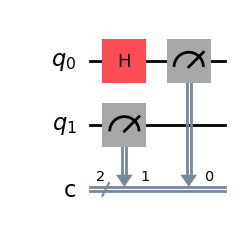


What should happen?
  Qubit 0: |0⟩ → H → (|0⟩+|1⟩)/√2  (superposition!)
  Qubit 1: |0⟩ → no gate → |0⟩     (stays |0⟩)

Predictions:
  Qubit 0 can measure 0 or 1 (50/50)
  Qubit 1 always measures 0
  Results: '00' or '10' (both equally likely)


In [15]:
# Apply H to qubit 0 only

print("Circuit: H on qubit 0, nothing on qubit 1")
print()

qc_h0 = QuantumCircuit(2, 2)
qc_h0.h(0)  # H gate on qubit 0 only
qc_h0.measure([0, 1], [0, 1])

print("Circuit diagram:")
display(qc_h0.draw('mpl'))

print()
print("What should happen?")
print("  Qubit 0: |0⟩ → H → (|0⟩+|1⟩)/√2  (superposition!)")
print("  Qubit 1: |0⟩ → no gate → |0⟩     (stays |0⟩)")
print()
print("Predictions:")
print("  Qubit 0 can measure 0 or 1 (50/50)")
print("  Qubit 1 always measures 0")
print("  Results: '00' or '10' (both equally likely)")

Results: {'00': 521, '01': 503}

Breakdown:
  '00': 521 times (50.9%)
  '10': 0 times (0.0%)
  '01': 503 times (49.1%) ← should be ~0
  '11': 0 times (0.0%) ← should be ~0



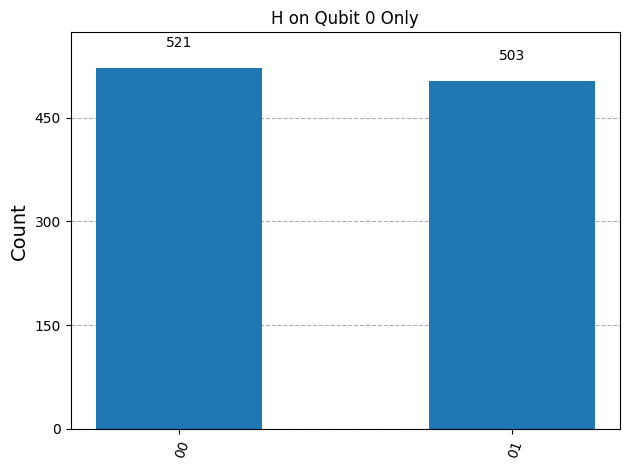

In [16]:
# Run the circuit

job = simulator.run(transpile(qc_h0, simulator), shots=1024)
counts = job.result().get_counts()

print("Results:", counts)
print()

# Analyze
count_00 = counts.get('00', 0)
count_10 = counts.get('10', 0)
count_01 = counts.get('01', 0)
count_11 = counts.get('11', 0)

print("Breakdown:")
print(f"  '00': {count_00} times ({count_00/1024*100:.1f}%)")
print(f"  '10': {count_10} times ({count_10/1024*100:.1f}%)")
print(f"  '01': {count_01} times ({count_01/1024*100:.1f}%) ← should be ~0")
print(f"  '11': {count_11} times ({count_11/1024*100:.1f}%) ← should be ~0")
print()

plot_histogram(counts, title='H on Qubit 0 Only')

Circuit: H on qubit 1, nothing on qubit 0

Circuit diagram:


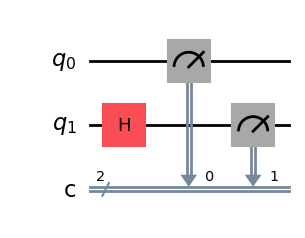


What should happen?
  Qubit 0: |0⟩ → no gate → |0⟩     (stays |0⟩)
  Qubit 1: |0⟩ → H → (|0⟩+|1⟩)/√2  (superposition!)

Predictions:
  Qubit 0 always measures 0
  Qubit 1 can measure 0 or 1 (50/50)
  Results: '00' or '01' (both equally likely)

Results: {'00': 513, '10': 511}

Breakdown:
  '00': 513 times (50.1%)
  '01': 0 times (0.0%)
  '10': 511 times (49.9%) ← should be ~0
  '11': 0 times (0.0%) ← should be ~0



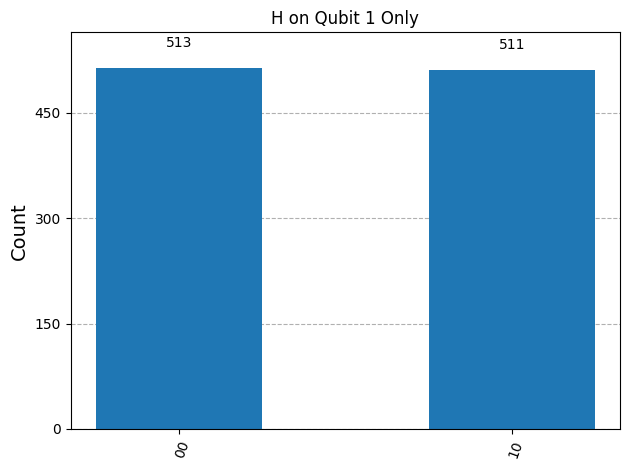

In [17]:
# Apply H to qubit 1 only

print("Circuit: H on qubit 1, nothing on qubit 0")
print()

qc_h1 = QuantumCircuit(2, 2)
qc_h1.h(1)  # H gate on qubit 1 only
qc_h1.measure([0, 1], [0, 1])

print("Circuit diagram:")
display(qc_h1.draw('mpl'))

print()
print("What should happen?")
print("  Qubit 0: |0⟩ → no gate → |0⟩     (stays |0⟩)")
print("  Qubit 1: |0⟩ → H → (|0⟩+|1⟩)/√2  (superposition!)")
print()
print("Predictions:")
print("  Qubit 0 always measures 0")
print("  Qubit 1 can measure 0 or 1 (50/50)")
print("  Results: '00' or '01' (both equally likely)")

# Run it
job = simulator.run(transpile(qc_h1, simulator), shots=1024)
counts = job.result().get_counts()

print()
print("Results:", counts)
print()

# Analyze
count_00 = counts.get('00', 0)
count_01 = counts.get('01', 0)
count_10 = counts.get('10', 0)
count_11 = counts.get('11', 0)

print("Breakdown:")
print(f"  '00': {count_00} times ({count_00/1024*100:.1f}%)")
print(f"  '01': {count_01} times ({count_01/1024*100:.1f}%)")
print(f"  '10': {count_10} times ({count_10/1024*100:.1f}%) ← should be ~0")
print(f"  '11': {count_11} times ({count_11/1024*100:.1f}%) ← should be ~0")
print()

plot_histogram(counts, title='H on Qubit 1 Only')

Circuit: H on both qubits

Circuit diagram:


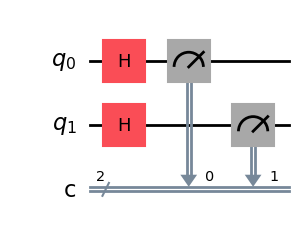


What should happen?
  Qubit 0: superposition (50/50)
  Qubit 1: superposition (50/50)
  Both qubits independent!

Predictions:
  All four outcomes equally likely:
  '00', '01', '10', '11' each ~25%

Results: {'10': 261, '11': 274, '01': 241, '00': 248}

  '00': 248 times (24.2%)
  '01': 241 times (23.5%)
  '10': 261 times (25.5%)
  '11': 274 times (26.8%)



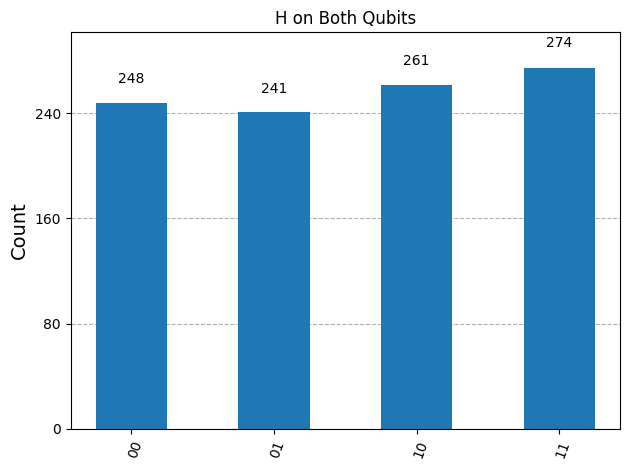

In [18]:
# Apply H to BOTH qubits

print("Circuit: H on both qubits")
print()

qc_h_both = QuantumCircuit(2, 2)
qc_h_both.h(0)  # H on qubit 0
qc_h_both.h(1)  # H on qubit 1
qc_h_both.measure([0, 1], [0, 1])

print("Circuit diagram:")
display(qc_h_both.draw('mpl'))

print()
print("What should happen?")
print("  Qubit 0: superposition (50/50)")
print("  Qubit 1: superposition (50/50)")
print("  Both qubits independent!")
print()
print("Predictions:")
print("  All four outcomes equally likely:")
print("  '00', '01', '10', '11' each ~25%")

# Run it
job = simulator.run(transpile(qc_h_both, simulator), shots=1024)
counts = job.result().get_counts()

print()
print("Results:", counts)
print()

# Analyze all four
for outcome in ['00', '01', '10', '11']:
    count = counts.get(outcome, 0)
    print(f"  '{outcome}': {count} times ({count/1024*100:.1f}%)")

print()
plot_histogram(counts, title='H on Both Qubits')